In [2]:
!pip install pyarrow

     ---------------------------------------- 20.0/20.0 MB 2.2 MB/s eta 0:00:00


In [120]:
!pip install pmdarima

     -------------------------------------- 572.0/572.0 kB 2.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import glob
import pyarrow as pa
import pyarrow.parquet as pq

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

import pmdarima as pm

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# 1. Read parq and csv files into dataframe

In [3]:
# read a tenant file with orders information:
df=pd.read_parquet('tenant_Horizon_Zone_Global.parq', engine='pyarrow')

In [4]:
df.head()

,order_date,company_id,tenant_id,order_id,order_line_id,product_category_name,product_id,channel_id,order_status_id,quantity,OriginalUnitPriceInclVat,OriginalUnitVat,CurrencyCode,EuroExchangeRate
0,2021-08-15,819,8805,58641972,786413855726,Slip,775290186,78,1,1,9.996,1.736,EUR,1.0
1,2021-07-07,819,8805,85621408,856213855035,Slip,775290186,78,1,1,8.000,1.388,EUR,1.0
2,2021-05-22,819,8805,54201528,442013855329,Slip,775290186,78,8,1,9.996,1.736,EUR,1.0
3,2021-07-18,819,8805,54431049,544313855393,Slip,775290186,78,6,1,8.000,1.388,EUR,1.0
4,2021-11-17,819,8805,94802334,248023855615,Slip,2461906901,78,1,1,8.996,1.560,EUR,1.0


In [5]:
# list column names:
column_name_check=list(df.columns)
column_name_check

['order_date',
 'company_id',
 'tenant_id',
 'order_id',
 'order_line_id',
 'product_category_name',
 'product_id',
 'channel_id',
 'order_status_id',
 'quantity',
 'OriginalUnitPriceInclVat',
 'OriginalUnitVat',
 'CurrencyCode',
 'EuroExchangeRate']

In [6]:
# Add parq files to a dataframe:
df_final = pd.DataFrame()
count_row = 0
for file in glob.glob("*.parq"):
    df_temp = pd.read_parquet(file, engine='pyarrow')
    column_name=list(df_temp.columns)
    nr_company = len(df_temp.company_id.unique())
    nr_tenant = len(df_temp.tenant_id.unique())
    
    #check to ensure column names are the same, company and tenant are unique in each file:
    if (column_name == column_name_check) & (nr_company == 1) & (nr_tenant == 1): 
        df_final = pd.concat([df_final, df_temp])
        nr_rows = len(df_temp.axes[0])
        count_row += nr_rows
        print(file + ' has ' + str(nr_rows) + ' rows and has been added.')
    else:
        print(file + ' has error and cannot be added to dataframe.')

tenant_Bitterballen_BV.parq has 589211 rows and has been added.
tenant_Horizon_Zone_Global.parq has 2913 rows and has been added.
tenant_Jelly_b2b.parq has 631617 rows and has been added.


In [7]:
# Add csv files to the same dataframe:
for file in glob.glob("*.csv"):
    df_temp = pd.read_csv(file)
    column_name=list(df_temp.columns)
    nr_company = len(df_temp.company_id.unique())
    nr_tenant = len(df_temp.tenant_id.unique())
    
    if (column_name == column_name_check) & (nr_company == 1) & (nr_tenant == 1):
        df_final = pd.concat([df_final, df_temp])
        nr_rows = len(df_temp.axes[0])
        count_row += nr_rows
        print(file + ' has ' + str(nr_rows) + ' rows and has been added.')
    else:
        print(file + ' has error and cannot be added to dataframe.')

tenant_Acme_Corp_APAC.csv has 2228 rows and has been added.
tenant_Acme_Corp_EMEA.csv has 1140 rows and has been added.
tenant_Acme_Corp_US.csv has 5319 rows and has been added.
tenant_BuYaYa BV.csv has 39623 rows and has been added.
tenant_Green_is_good_BV.csv has 98434 rows and has been added.
tenant_Horizon_Zone_APAC.csv has 5335 rows and has been added.
tenant_Horizon_Zone_CA.csv has 5229 rows and has been added.
tenant_Horizon_Zone_EMEA.csv has 13192 rows and has been added.
tenant_Horizon_Zone_US.csv has 1416 rows and has been added.
tenant_Jelly b2c.csv has 32561 rows and has been added.
tenant_Sofa_team_BV.csv has 434 rows and has been added.


In [8]:
df_final.head()

,order_date,company_id,tenant_id,order_id,order_line_id,product_category_name,product_id,channel_id,order_status_id,quantity,OriginalUnitPriceInclVat,OriginalUnitVat,CurrencyCode,EuroExchangeRate
0,2022-01-19,392,7406,4155075457,61550753855797,Auto accessoires,60932905581,1271,1,1,7.516,1.2,EUR,1.0
1,2022-01-18,392,7406,9285965277,42859653855886,None,12203908086,64,1,1,7.196,1.2,EUR,1.0
2,2022-01-18,392,7406,5176965060,9176965385511,Glasservies,7391901721,78,1,1,6.916,1.2,EUR,1.0
3,2022-01-19,392,7406,3858075698,58580753855749,Pannen,1652905216,78,1,1,6.916,1.2,EUR,1.0
4,2022-01-19,392,7406,3068075412,9068075385575,Pannen,1652905216,78,1,1,6.916,1.2,EUR,1.0


In [9]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1428652 entries, 0 to 433
Data columns (total 14 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   order_date                1428652 non-null  object 
 1   company_id                1428652 non-null  int64  
 2   tenant_id                 1428652 non-null  int64  
 3   order_id                  1428652 non-null  int64  
 4   order_line_id             1428652 non-null  int64  
 5   product_category_name     1375077 non-null  object 
 6   product_id                1428652 non-null  int64  
 7   channel_id                1428652 non-null  int64  
 8   order_status_id           1428652 non-null  int64  
 9   quantity                  1428652 non-null  int64  
 10  OriginalUnitPriceInclVat  1428652 non-null  float64
 11  OriginalUnitVat           1428652 non-null  float64
 12  CurrencyCode              1428652 non-null  object 
 13  EuroExchangeRate          13287

# 2. Some intial data quality check

In [10]:
# find min and maz of each column:
df_final.agg(['min', 'max'])


C:\Users\aiden.pham\AppData\Local\Temp\ipykernel_1188\117687.py:2: FutureWarning: ['product_category_name'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  df_final.agg(['min', 'max'])


,order_date,company_id,tenant_id,order_id,order_line_id,product_id,channel_id,order_status_id,quantity,OriginalUnitPriceInclVat,OriginalUnitVat,CurrencyCode,EuroExchangeRate
min,2019-02-11,223,1736,2880,36385595,14890762,1,0,-147,0.000,0.000,EUR,0.8179
max,2022-02-02,973,9305,9999992659,99999843855904,9999914902180,1532,10,90,3659.916,731.984,USD,1.2025


In [11]:
count_row

1428652

In [16]:
# check number of null values in each column:
print('Number of Null rows:')
print(df_final.isnull().sum(axis = 0))

# check % of null values in each column:
print('')
print('% of Null rows:')
print(df_final.isnull().sum(axis = 0) / count_row * 100)

# Product_category_name has 3.75% Null, and EuroExchangeRate has 6.99% Null

Number of Null rows:
order_date                      0
company_id                      0
tenant_id                       0
order_id                        0
order_line_id                   0
product_category_name       53575
product_id                      0
channel_id                      0
order_status_id                 0
quantity                        0
OriginalUnitPriceInclVat        0
OriginalUnitVat                 0
CurrencyCode                    0
EuroExchangeRate            99863
dtype: int64

% of Null rows:
order_date                  0.000000
company_id                  0.000000
tenant_id                   0.000000
order_id                    0.000000
order_line_id               0.000000
product_category_name       3.750038
product_id                  0.000000
channel_id                  0.000000
order_status_id             0.000000
quantity                    0.000000
OriginalUnitPriceInclVat    0.000000
OriginalUnitVat             0.000000
CurrencyCode                0

In [15]:
# check rows with Null Product category name
df_final[df_final.product_category_name.isnull()]

# Product category name can be filled by checking other rows with similar product_id/channel_id/etc.

,order_date,company_id,tenant_id,order_id,order_line_id,product_category_name,product_id,channel_id,order_status_id,quantity,OriginalUnitPriceInclVat,OriginalUnitVat,CurrencyCode,EuroExchangeRate
1,2022-01-18,392,7406,9285965277,42859653855886,None,12203908086,64,1,1,7.196,1.200,EUR,1.0
20,2022-01-19,392,7406,7180175495,41801753855279,None,21042908923,1343,1,1,11.996,2.000,GBP,1.0
60,2022-01-18,392,7406,929596545,42959653855117,None,78592909119,76,1,1,4.196,0.728,EUR,1.0
61,2022-01-18,392,7406,929596545,82959653855156,None,78492900636,76,1,1,3.596,0.624,EUR,1.0
63,2022-01-19,392,7406,3279075257,5279075385552,None,57492906171,76,1,2,4.180,0.724,EUR,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10273,2021-12-13,819,8951,4526884,252683855231,NaN,81163900429,1369,1,1,15.980,2.772,EUR,1.0
10336,2021-12-07,819,8951,42648250,926483855390,NaN,90514907765,1369,1,1,33.000,5.728,EUR,1.0
11059,2021-10-06,819,8951,77506701,875063855172,NaN,27291903982,1369,8,1,26.400,4.580,EUR,1.0
11280,2021-11-29,819,8951,95708660,257083855083,NaN,4901490917,1369,1,1,19.800,3.436,EUR,1.0


In [17]:
# check rows with Null EuroExchangeRate
df_temp = df_final[df_final.EuroExchangeRate.isnull()]
df_temp

,order_date,company_id,tenant_id,order_id,order_line_id,product_category_name,product_id,channel_id,order_status_id,quantity,OriginalUnitPriceInclVat,OriginalUnitVat,CurrencyCode,EuroExchangeRate
17404,2020-03-31,392,7406,539863719,3398633855840,Kasten,2098900198,1321,1,1,2.70,0.000,EUR,NaN
17442,2019-07-26,392,7406,56633554,666333855342,Oordopjes,4002905164,76,1,1,3.80,0.660,EUR,NaN
17443,2019-07-25,392,7406,24613493,646133855245,Oordopjes,6751901575,76,1,1,3.80,0.660,EUR,NaN
17444,2019-07-26,392,7406,13233315,332333855765,Oordopjes,6751901575,76,1,1,3.80,0.660,EUR,NaN
17445,2019-07-26,392,7406,20733618,707333855385,Oordopjes,6751901575,76,1,1,3.80,0.660,EUR,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98415,2020-01-09,427,6631,32839359,9283933855803,Enkellaarsjes,9822902909799,58,1,1,15.98,2.772,EUR,NaN
98418,2020-04-08,427,6631,153864682,7538643855406,Lage sneakers,5222092902240,1340,1,1,15.98,2.772,EUR,NaN
98419,2020-04-08,427,6631,194664767,1946643855976,Lage sneakers,5222092902240,1340,1,1,15.98,2.772,EUR,NaN
98423,2020-04-09,427,6631,454274347,9542743855772,Teenslippers,9337432906365,1340,1,1,15.98,2.772,EUR,NaN


In [18]:
# check what currency does not have exchange rate:
df_temp['CurrencyCode'].value_counts()

# most are EUR, which should have Exchange rate 1.0
# some are GBP. Missing ExchangeRate can be found by taking exchange rate from rows with GBP CurrencyCode (on same order_date)

EUR    94904
GBP     4959
Name: CurrencyCode, dtype: int64

# 3. Save all data into a parquet file

In [19]:
# save orders table (from csv and parq) as parquet file:
df_final.to_parquet('all_tenants.parquet', engine='pyarrow', index=False)

In [20]:
# convert json files to dataframe, and combine all in a dictionary:
dimension_tables = {}
for file in glob.glob("*.json"):
    dimension_tables[file.replace('.json','')] = pd.read_json(file)

In [21]:
for dim in dimension_tables:
    print(dim)

channel
company
order_status
tenant


In [22]:
dimension_tables['company']

,company_id,company_name
0,223,Acme Corp
1,819,Horizon Zone
2,392,Bitterballen Fashion
3,973,Sofa team tech
4,427,Green is good
5,394,BuYaYa BV
6,485,Jelly BV


In [70]:
# save dimension tables (from json) as parquet files:
for dim in dimension_tables:
    dimension_tables[dim].to_parquet(dim+'.parquet', engine='pyarrow', index=False)

# 4. ARIMA forecasting

In [35]:
df = pd.read_csv('ARIMA/fietsaccessoires.csv').sort_values(by=['order_date']).reset_index(drop=True)

In [36]:
df_train = df[pd.to_datetime(df.order_date) <= pd.to_datetime('2022-01-02')]
df_test = df[pd.to_datetime(df.order_date) > pd.to_datetime('2022-01-02')]

C:\Users\aiden.pham\AppData\Local\Temp\ipykernel_10592\1403884881.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['order_date'] = pd.to_datetime(df_temp['order_date'])


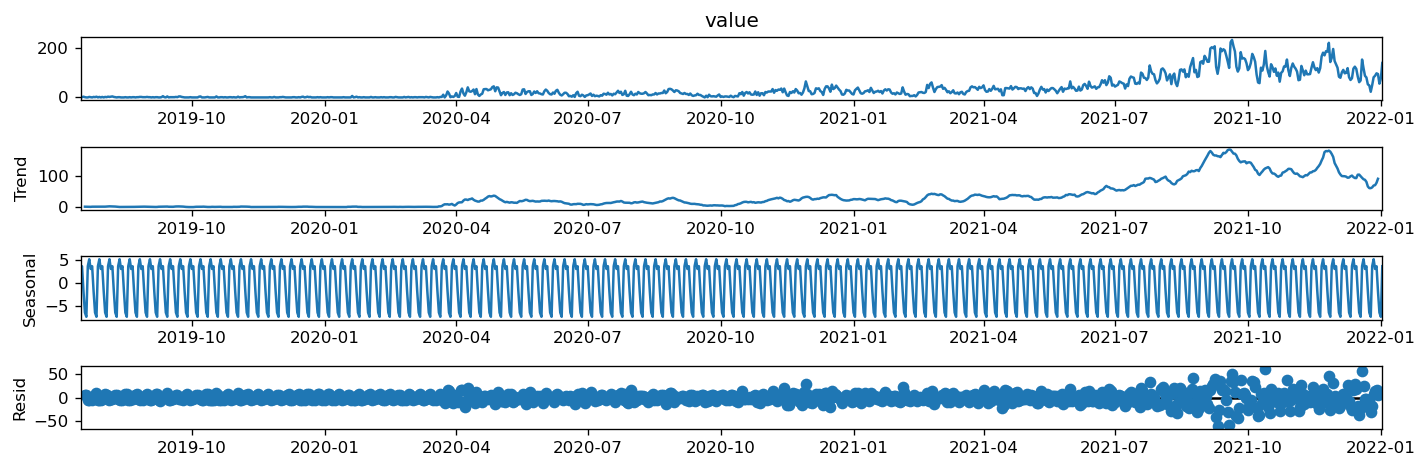

In [336]:
# Seasonal decompose
plt.rcParams.update({'figure.figsize':(12,4), 'figure.dpi':120})

df_temp = df_train
df_temp['order_date'] = pd.to_datetime(df_temp['order_date'])
df_temp = df_temp.set_index('order_date')
decomp = seasonal_decompose(df_temp['value'])
decomp.plot()
plt.show()

# There is seasonality every 7 days --> To fit a simple non-seasonal ARIMA first, then compare with seasonal ARIMA

In [37]:
df_train = df_train.drop('order_date', axis=1)
df_test = df_test.drop('order_date', axis=1)

## 4.1 Non-seasonal ARIMA (Manual)

ARIMA (p,d,q)

C:\Users\aiden.pham\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


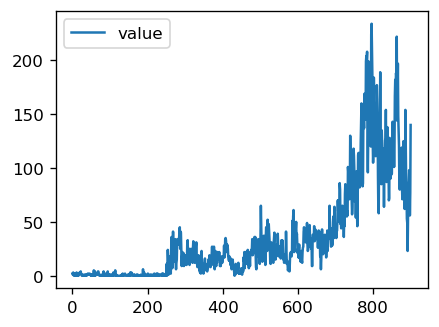

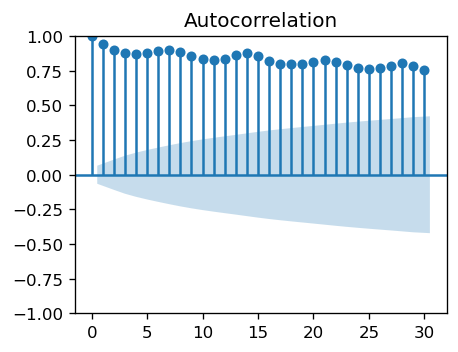

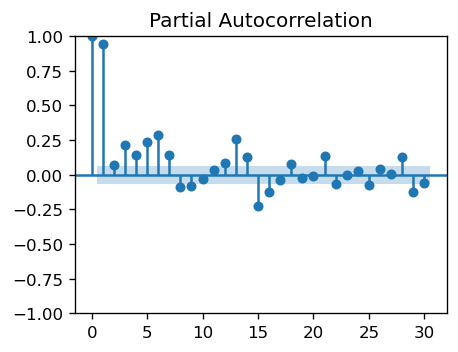

In [45]:
# Original series:
plt.rcParams.update({'figure.figsize':(4,3), 'figure.dpi':120})

df_train.plot()
acf_original = plot_acf(df_train)
pacf_original = plot_pacf(df_train)

# Original series has lots of autocorrelation, os it is non-stationary --> we need to take 1st differencing

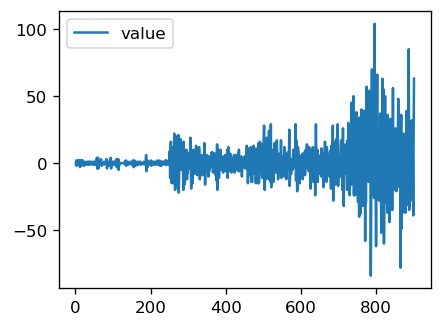

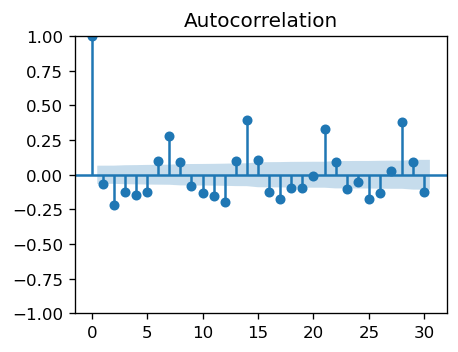

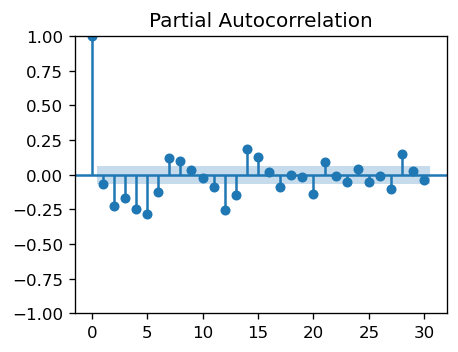

In [339]:
# 1st differencing
df_train_diff = df_train.diff().dropna()
df_train_diff.plot()
acf_diff = plot_acf(df_train_diff)
pacf_diff = plot_pacf(df_train_diff)

# 1st differencing has less auto-correlation

In [226]:
# Augmented Dickey-Fuller test (if p < 0.05 --> the series is stationary)
adf_test = adfuller(df_train)
print(f'p-value original series: {adf_test[1]}')

adf_test = adfuller(df_train.diff().dropna())
print(f'p-value 1st differencing: {adf_test[1]}')

adf_test = adfuller(df_train.diff().diff().dropna())
print(f'p-value 2nd differencing: {adf_test[1]}')

# from the above result, 1st differencing is stationaty --> set d = 1
# looking at the ACF & PACF graph of 1st differencing, correlation of all lags are week --> start with p = 0 and q = 0 

p-value original series: 0.6824788745731261
p-value 1st differencing: 1.4016618701845823e-11
p-value 2nd differencing: 1.4830192174967184e-22


In [44]:
# Train non-seasonal ARIMA model:
model = ARIMA(df_train, order=(0,1,0))
model_fit = model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  value   No. Observations:                  902
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -3702.994
Date:                Mon, 14 Nov 2022   AIC                           7407.987
Time:                        14:49:23   BIC                           7412.791
Sample:                             0   HQIC                          7409.822
                                - 902                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       217.4293      4.335     50.152      0.000     208.932     225.927
===================================================================================
Ljung-Box (L1) (Q):                   4.33   Jarque-Bera (JB):              3195.51
Prob(Q):                              0.04   Prob(JB):                         0.00
Heteroskedasticity (H):              22.85   Skew:                             0.62
Prob(H) (two-sided):                  0.00   Kurtosis:                        12.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 4.2 Non-seasonal ARIMA (Auto search)

In [22]:
# Train auto ARIMA model
auto_arima = pm.auto_arima(df_train,                         
                           trace=True, stepwise=True, seasonal=False)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=7209.894, Time=1.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=7409.890, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=7407.484, Time=0.15 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7403.145, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=7407.987, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=7260.282, Time=0.34 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=7253.019, Time=0.32 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=7180.211, Time=1.36 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=7249.663, Time=0.45 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=7101.054, Time=1.78 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=7226.987, Time=0.62 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=7087.559, Time=1.66 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=7199.193, Time=0.52 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=7169.482, Time=1.57 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept

In [27]:
auto_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  902
Model:               SARIMAX(5, 1, 2)   Log Likelihood               -3534.912
Date:                Mon, 14 Nov 2022   AIC                           7085.824
Time:                        14:41:17   BIC                           7124.252
Sample:                             0   HQIC                          7100.503
                                - 902                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8053      0.023     34.273      0.000       0.759       0.851
ar.L2         -0.8558      0.028    -30.703      0.000      -0.910      -0.801
ar.L3         -0.0520      0.032     -1.610      0.107      -0.115       0.011
ar.L4         -0.2508      0.027     -9.165      0.000      -0.304      -0.197
ar.L5         -0.1238      0.021     -5.833      0.000      -0.165      -0.082
ma.L1         -1.1443      0.012    -96.813      0.000      -1.167      -1.121
ma.L2          0.9044      0.012     76.641      0.000       0.881       0.927
sigma2       150.1465      3.352     44.790      0.000     143.576     156.717
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              2359.91
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):              18.95   Skew:                             0.58
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 4.3 Seasonal ARIMA (SARIMA) (Manual)

SARIMA (p,d,q) (P,D,Q,M)

In [41]:
df_seasonal = df[pd.to_datetime(df.order_date) <= pd.to_datetime('2022-01-02')].drop('order_date', axis=1)
df_seasonal['value']=df_seasonal['value']-df_seasonal['value'].shift(7)
df_seasonal = df_seasonal[7:].reset_index()
df_seasonal = df_seasonal.drop('index',axis=1)

C:\Users\aiden.pham\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


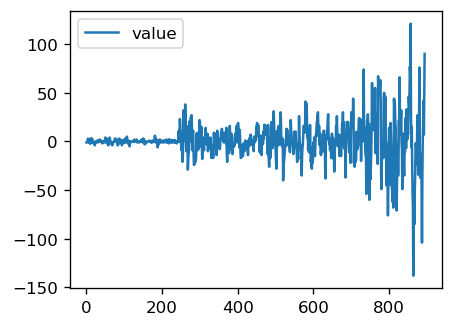

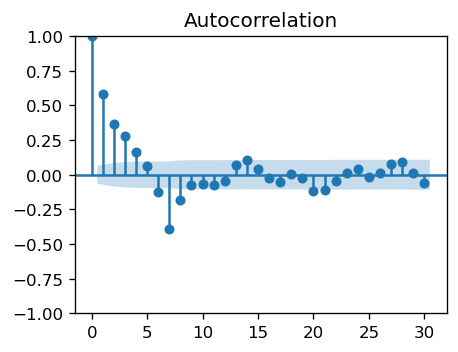

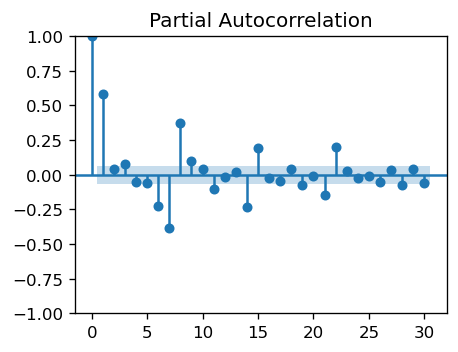

In [341]:
#Seasonality:
df_seasonal.plot()
acf_original = plot_acf(df_seasonal)
pacf_original = plot_pacf(df_seasonal)

In [249]:
# Augmented Dickey-Fuller test
adf_test = adfuller(df_seasonal)
print(f'p-value original seasonality: {adf_test[1]}')

adf_test = adfuller(df_seasonal.diff().dropna())
print(f'p-value seasonality 1st differencing: {adf_test[1]}')

adf_test = adfuller(df_seasonal.diff().diff().dropna())
print(f'p-value seasonality 2nd differencing: {adf_test[1]}')

# Original seasonality is already stationary --> set D = 0
# Lag 1 in PACF graph is significant --> set P = 1
# Lag 1 to 4 in ACF graph is significant --> set Q = 4
# Cycle happens every 7 days --> set M = 7

p-value original seasonality: 7.114943259504384e-08
p-value seasonality 1st differencing: 3.2087504162783935e-21
p-value seasonality 2nd differencing: 3.1158536909626216e-23


In [38]:
# Train seasonal ARIMA model
model_seasonal = ARIMA(df_train, order=(0,1,0), seasonal_order =(1,0,4,7))
model_fit_seasonal = model_seasonal.fit()
model_fit_seasonal.summary()

# p value > 0.05 for 3rd and 4th MA coefficiency --> reduce Q to 2

<class 'statsmodels.iolib.summary.Summary'>
"""
                                         SARIMAX Results                                          
==================================================================================================
Dep. Variable:                                      value   No. Observations:                  902
Model:             ARIMA(0, 1, 0)x(1, 0, [1, 2, 3, 4], 7)   Log Likelihood               -3554.240
Date:                                    Mon, 14 Nov 2022   AIC                           7120.480
Time:                                            14:43:08   BIC                           7149.301
Sample:                                                 0   HQIC                          7131.489
                                                    - 902                                         
Covariance Type:                                      opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L7        0.9651      0.009    102.388      0.000       0.947       0.984
ma.S.L7       -0.9416      0.025    -38.037      0.000      -0.990      -0.893
ma.S.L14       0.1772      0.032      5.452      0.000       0.113       0.241
ma.S.L21      -0.0274      0.032     -0.871      0.384      -0.089       0.034
ma.S.L28       0.0117      0.027      0.433      0.665      -0.041       0.065
sigma2       155.1226      3.732     41.570      0.000     147.809     162.436
===================================================================================
Ljung-Box (L1) (Q):                  34.58   Jarque-Bera (JB):              1654.24
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):              17.24   Skew:                             0.17
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [39]:
# Re-Train seasonal ARIMA model
model_seasonal = ARIMA(df_train, order=(0,1,0), seasonal_order =(1,0,2,7))
model_fit_seasonal = model_seasonal.fit()
model_fit_seasonal.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                value   No. Observations:                  902
Model:             ARIMA(0, 1, 0)x(1, 0, [1, 2], 7)   Log Likelihood               -3554.435
Date:                              Mon, 14 Nov 2022   AIC                           7116.870
Time:                                      14:43:12   BIC                           7136.084
Sample:                                           0   HQIC                          7124.210
                                              - 902                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L7        0.9642      0.009    108.784      0.000       0.947       0.982
ma.S.L7       -0.9393      0.023    -41.206      0.000      -0.984      -0.895
ma.S.L14       0.1623      0.024      6.675      0.000       0.115       0.210
sigma2       155.1932      3.631     42.745      0.000     148.077     162.309
===================================================================================
Ljung-Box (L1) (Q):                  33.51   Jarque-Bera (JB):              1647.37
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):              17.27   Skew:                             0.17
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.62
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 4.4 Seasonal ARIMA (SARIMA) (Auto search)

In [40]:
auto_arima_seasonal = pm.auto_arima(df_train, 
                           start_p=0, d=1, start_q=0,
                           max_p=5, max_q=5,
                           start_P=0, D=0, start_Q=0,
                           max_P=5, max_Q=5,
                           error_action = 'warn', m=7,
                           trace=True, stepwise=True, seasonal=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=7409.890, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=7317.733, Time=0.28 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=7348.265, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=7407.987, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=7407.484, Time=0.11 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=7171.448, Time=0.54 sec
 ARIMA(1,1,0)(3,0,0)[7] intercept   : AIC=7137.321, Time=1.15 sec
 ARIMA(1,1,0)(4,0,0)[7] intercept   : AIC=7091.859, Time=2.08 sec
 ARIMA(1,1,0)(5,0,0)[7] intercept   : AIC=7092.533, Time=4.57 sec
 ARIMA(1,1,0)(4,0,1)[7] intercept   : AIC=7084.770, Time=2.97 sec
 ARIMA(1,1,0)(3,0,1)[7] intercept   : AIC=7084.349, Time=1.52 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=7083.398, Time=0.68 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=7103.955, Time=0.45 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=7075.120, Time=1.35 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept

In [42]:
auto_arima_seasonal.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                         SARIMAX Results                                         
=================================================================================================
Dep. Variable:                                         y   No. Observations:                  902
Model:             SARIMAX(5, 1, 0)x(2, 0, [1, 2, 3], 7)   Log Likelihood               -3492.086
Date:                                   Mon, 14 Nov 2022   AIC                           7006.171
Time:                                           14:48:42   BIC                           7059.010
Sample:                                                0   HQIC                          7026.355
                                                   - 902                                         
Covariance Type:                                     opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3005      0.020    -15.145      0.000      -0.339      -0.262
ar.L2         -0.2712      0.026    -10.519      0.000      -0.322      -0.221
ar.L3         -0.1699      0.023     -7.507      0.000      -0.214      -0.126
ar.L4         -0.1711      0.022     -7.936      0.000      -0.213      -0.129
ar.L5         -0.1583      0.022     -7.249      0.000      -0.201      -0.115
ar.S.L7        0.0404      0.042      0.960      0.337      -0.042       0.123
ar.S.L14       0.8984      0.041     21.963      0.000       0.818       0.979
ma.S.L7       -0.0576      0.047     -1.230      0.219      -0.149       0.034
ma.S.L14      -0.6785      0.055    -12.403      0.000      -0.786      -0.571
ma.S.L21       0.0957      0.030      3.146      0.002       0.036       0.155
sigma2       135.0465      3.566     37.869      0.000     128.057     142.036
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):              1130.50
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):              17.10   Skew:                             0.39
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 4.5 Validation by comparing forecast with actual data

(800.0, 940.0)

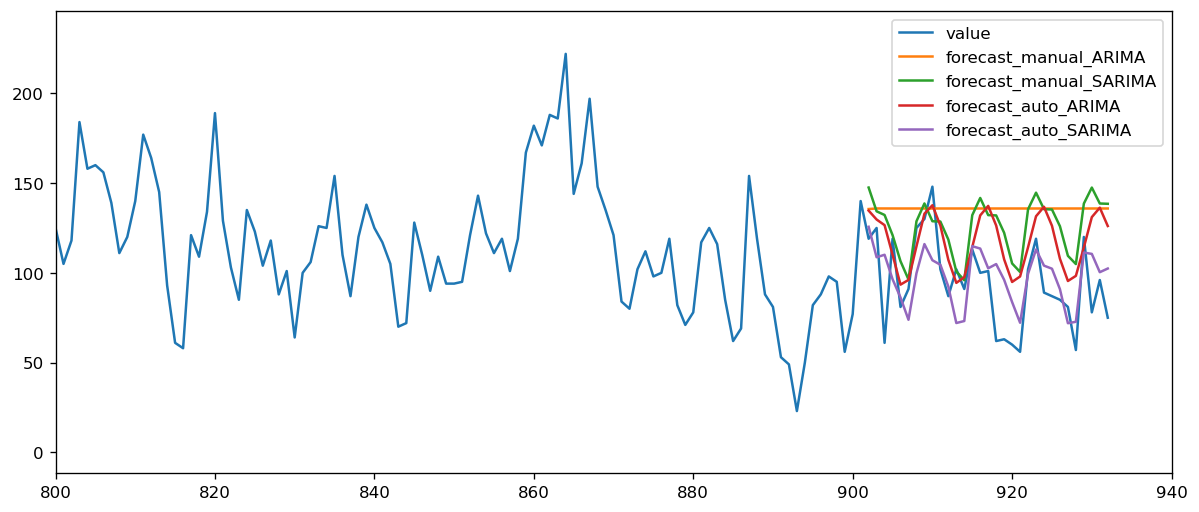

In [43]:
plt.rcParams.update({'figure.figsize':(12,5), 'figure.dpi':120})

# Compare forecast made by different models:
forecast_test_manual_ARIMA = model_fit.forecast(len(df_test))
df['forecast_manual_ARIMA'] = [None]*len(df_train) + list(forecast_test_manual_ARIMA)
forecast_test_manual_SARIMA = model_fit_seasonal.forecast(len(df_test))
df['forecast_manual_SARIMA'] = [None]*len(df_train) + list(forecast_test_manual_SARIMA)
forecast_test_auto_ARIMA = auto_arima.predict(n_periods=len(df_test))
df['forecast_auto_ARIMA'] = [None]*len(df_train) + list(forecast_test_auto_ARIMA)
forecast_test_auto_SARIMA = auto_arima_seasonal.predict(n_periods=len(df_test))
df['forecast_auto_SARIMA'] = [None]*len(df_train) + list(forecast_test_auto_SARIMA)
df.plot().set_xlim([800,940])

In [292]:
mae = mean_absolute_error(df_test, forecast_test_manual_ARIMA)
mape = mean_absolute_percentage_error(df_test, forecast_test_manual_ARIMA)
rmse = np.sqrt(mean_squared_error(df_test, forecast_test_manual_ARIMA))

print(f'mae - manual - ARIMA: {mae}')
print(f'mape - manual - ARIMA: {mape}')
print(f'rmse - manual - ARIMA: {rmse}')

mae - manual - ARIMA: 46.16129032258065
mape - manual - ARIMA: 0.5924738712629284
rmse - manual - ARIMA: 51.47219731830179


In [46]:
mae = mean_absolute_error(df_test, forecast_test_auto_ARIMA)
mape = mean_absolute_percentage_error(df_test, forecast_test_auto_ARIMA)
rmse = np.sqrt(mean_squared_error(df_test, forecast_test_auto_ARIMA))

print(f'mae - auto - ARIMA: {mae}')
print(f'mape - auto - ARIMA: {mape}')
print(f'rmse - auto - ARIMA: {rmse}')

mae - auto - ARIMA: 25.50872487347351
mape - auto - ARIMA: 0.33238012853962373
rmse - auto - ARIMA: 31.75083112002245


In [305]:
mae = mean_absolute_error(df_test, forecast_test_manual_SARIMA)
mape = mean_absolute_percentage_error(df_test, forecast_test_manual_SARIMA)
rmse = np.sqrt(mean_squared_error(df_test, forecast_test_manual_SARIMA))

print(f'mae - manual - SARIMA: {mae}')
print(f'mape - manual - SARIMA: {mape}')
print(f'rmse - manual - SARIMA: {rmse}')

mae - manual - SARIMA: 32.71230388197109
mape - manual - SARIMA: 0.4171171195489108
rmse - manual - SARIMA: 38.70189361481308


In [354]:
mae = mean_absolute_error(df_test, forecast_test_auto_SARIMA)
mape = mean_absolute_percentage_error(df_test, forecast_test_auto_SARIMA)
rmse = np.sqrt(mean_squared_error(df_test, forecast_test_auto_SARIMA))

print(f'mae - auto - SARIMA: {mae}')
print(f'mape - auto - SARIMA: {mape}')
print(f'rmse - auto - SARIMA: {rmse}')

mae - auto - SARIMA: 17.038138595194035
mape - auto - SARIMA: 0.20780635484351895
rmse - auto - SARIMA: 21.273850733236483
